# Drzewa decyzyjne

1. Załaduj zbiór Adult Census Income przez fetch openml(’adult’, version=2)
i wykonaj eksploracyjną analizę danych: typy kolumn, braki danych, rozkład klas, podział cech na numeryczne i kategoryczne, P(target=1 |
cecha) dla cech kategorycznych.

In [1]:
from sklearn.datasets import fetch_openml
import pandas as pd
import numpy as np

dataset_name = "Adult Census Income"
try:
    ds = fetch_openml('adult', version=2, as_frame=True, parser='auto')
    df = ds.frame.copy()
    df['income'] = (df['class'] == '>50K').astype(int)
    df = df.drop(columns=['class'])
    target_col = 'income'
    print(f"Wczytano {dataset_name}: {df.shape}")
    print(f"Rozkład klas: {df[target_col].value_counts().to_dict()}  "
          f"(baseline = {df[target_col].mean():.3f})")
except Exception as e:
    print(f"OpenML niedostępny")

df.head()

Wczytano Adult Census Income: (48842, 15)
Rozkład klas: {0: 37155, 1: 11687}  (baseline = 0.239)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,0


In [2]:
info = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing': df.isnull().sum(),
    'missing_%': (df.isnull().sum() / len(df) * 100).round(2),
    'nunique': df.nunique()
})
info

,dtype,missing,missing_%,nunique
age,int64,0,0.00,74
workclass,category,2799,5.73,8
fnlwgt,int64,0,0.00,28523
education,category,0,0.00,16
education-num,int64,0,0.00,16
marital-status,category,0,0.00,7
occupation,category,2809,5.75,14
relationship,category,0,0.00,6
race,category,0,0.00,5
sex,category,0,0.00,2


In [3]:
num_cols = df.select_dtypes(include=[np.number]).columns.drop(target_col).tolist()
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Numeric ({len(num_cols)}): {num_cols}")
print(f"Categoric ({len(cat_cols)}): {cat_cols}")

Numeric (6): ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categoric (8): ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


In [4]:
df[num_cols].describe().round(2)

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,48842.00,48842.00,48842.00,48842.00,48842.0,48842.00
mean,38.64,189664.13,10.08,1079.07,87.5,40.42
std,13.71,105604.03,2.57,7452.02,403.0,12.39
min,17.00,12285.00,1.00,0.00,0.0,1.00
25%,28.00,117550.50,9.00,0.00,0.0,40.00
50%,37.00,178144.50,10.00,0.00,0.0,40.00
75%,48.00,237642.00,12.00,0.00,0.0,45.00
max,90.00,1490400.00,16.00,99999.00,4356.0,99.00


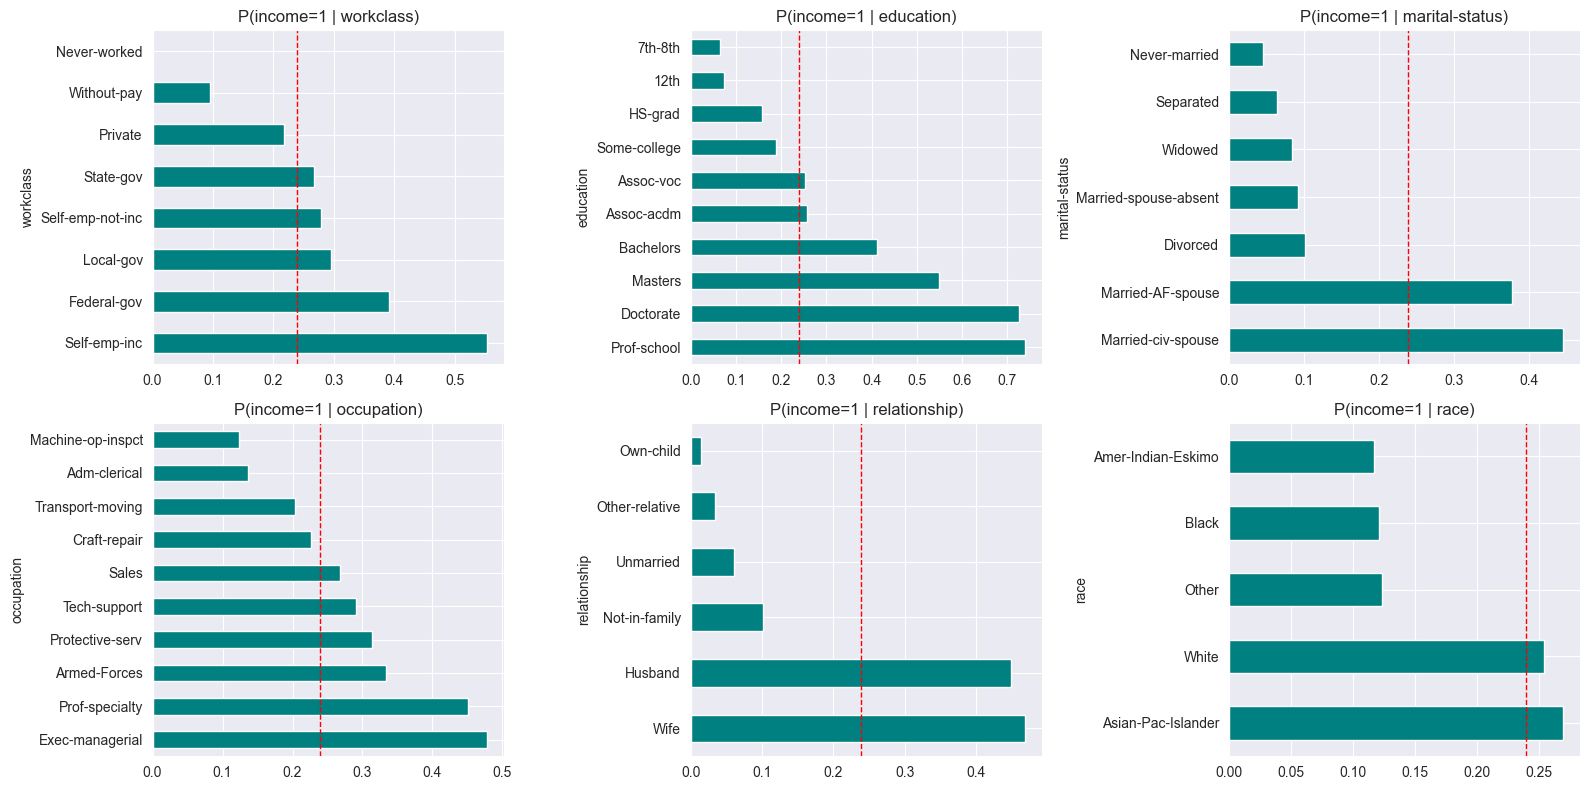

In [5]:
import matplotlib.pyplot as plt

# Współczynnik klasy pozytywnej w grupach kategorii
if cat_cols:
    fig, axes = plt.subplots(2, min(3, len(cat_cols)), figsize=(16, 8))
    axes = np.array(axes).ravel()
    for i, c in enumerate(cat_cols[:6]):
        vc = df.groupby(c, observed=True)[target_col].mean().sort_values(ascending=False).head(10)
        vc.plot(kind='barh', ax=axes[i], color='teal')
        axes[i].axvline(df[target_col].mean(), color='red', ls='--', lw=1)
        axes[i].set_title(f"P({target_col}=1 | {c})")
        axes[i].set_xlabel('')
    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    plt.tight_layout(); plt.show()

2. Zbuduj pipeline preprocessingu używając ColumnTransformer, łącząc SimpleImputer
z OrdinalEncoder dla kategorii. Dokonaj stratyfikowanego podziału 75%/25%.

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
RNG = 42

# Pipeline preprocessingu, dla drzew stosujemy OrdinalEncoder
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
])
categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
])
preproc = ColumnTransformer([
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols),
], remainder='drop')

feature_names = num_cols + cat_cols

X = df.drop(columns=target_col)
y = df[target_col].astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RNG
)
print(f"Trening: {X_train.shape}   Test: {X_test.shape}")
print(f"Rozkład klas (trening): {pd.Series(y_train).value_counts(normalize=True).round(3).to_dict()}")

Trening: (36631, 14)   Test: (12211, 14)
Rozkład klas (trening): {0: 0.761, 1: 0.239}


3. Naucz pełne drzewo (bez regularyzacji) i zaobserwuj overfit: różnicę między dokładnością na zbiorze treningowym i testowym. Jaka głębokość
drzewa została osiągnięta?

In [7]:
from sklearn.tree import DecisionTreeClassifier

base_pipe = Pipeline([
    ('preproc', preproc),
    ('clf', DecisionTreeClassifier(random_state=RNG))
])

# Baseline: pełne drzewo, bez przycinania
base_pipe.fit(X_train, y_train)
print(f"Pełne drzewo: głębokość: {base_pipe['clf'].get_depth()}, "
      f"liście: {base_pipe['clf'].get_n_leaves()}")
print(f"Trening accuracy: {base_pipe.score(X_train, y_train):.4f}")
print(f"Test accuracy:    {base_pipe.score(X_test, y_test):.4f}")

Pełne drzewo: głębokość: 44, liście: 5450
Trening accuracy: 0.9999
Test accuracy:    0.8178


4. Za pomocą 10-krotnej walidacji krzyżowej dla max depth ∈ {1, . . . , 20}
zilustruj krzywą bias-variance. Zidentyfikuj optymalną głębokość.

In [8]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# CV over max_depth: pokazuje bias-variance
depths = list(range(1, 21))
kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=RNG)

cv_scores = []
for d in depths:
    pipe = Pipeline([
        ('preproc', preproc),
        ('clf', DecisionTreeClassifier(max_depth=d, random_state=RNG))
    ])
    s = cross_val_score(pipe, X_train, y_train, cv=kf, scoring='balanced_accuracy', n_jobs=-1)
    cv_scores.append((s.mean(), s.std()))

cv_df = pd.DataFrame(cv_scores, index=depths, columns=['mean', 'std'])
best_d = cv_df['mean'].idxmax()
print(f"Najlepsza max_depth (10-fold CV, balanced_accuracy): {best_d}  "
      f"CV = {cv_df.loc[best_d, 'mean']:.4f} ± {cv_df.loc[best_d, 'std']:.4f}")

Najlepsza max_depth (10-fold CV, balanced_accuracy): 10  CV = 0.7785 ± 0.0117


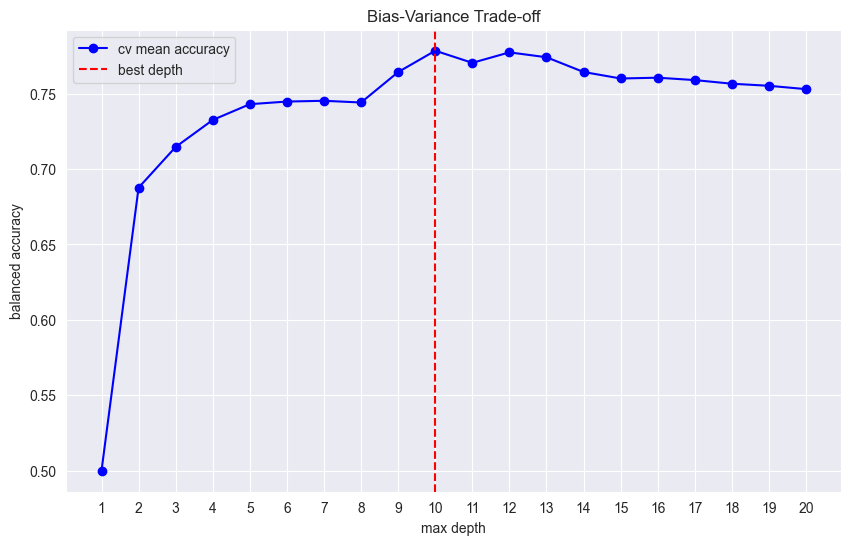

In [9]:
plt.figure(figsize=(10, 6))
plt.plot(cv_df.index, cv_df['mean'], marker='o', color='blue', label='cv mean accuracy')
plt.axvline(best_d, color='red', linestyle='--', label=f'best depth')
plt.title('Bias-Variance Trade-off')
plt.xlabel('max depth')
plt.ylabel('balanced accuracy')
plt.xticks(cv_df.index)
plt.legend()
plt.show()

Dzięki 10-krotnej walidacji krzyżowej otrzymano optymalną głębokość równą 10. Jak widać na wykresie, dla tej głębokości zachodzi kompromis pomiędzy obciążeniem a wariancją. Otrzymano 77.85% dokładności przy stosunkowo małym odchyleniu std równym 0.0117.

5. Cost-Complexity Pruning. Dla pełnego drzewa wywołaj:
full tree.cost complexity pruning path() uzyskując sekwencję α0 <
α1 < . . . < αm. Dla każdego α:
- wytrenuj drzewo z ccp alpha=α,
- zapisz głębokość, liczbę liści, train accuracy, test accuracy,
- zwizualizuj train/test accuracy oraz liczbę liści w funkcji α

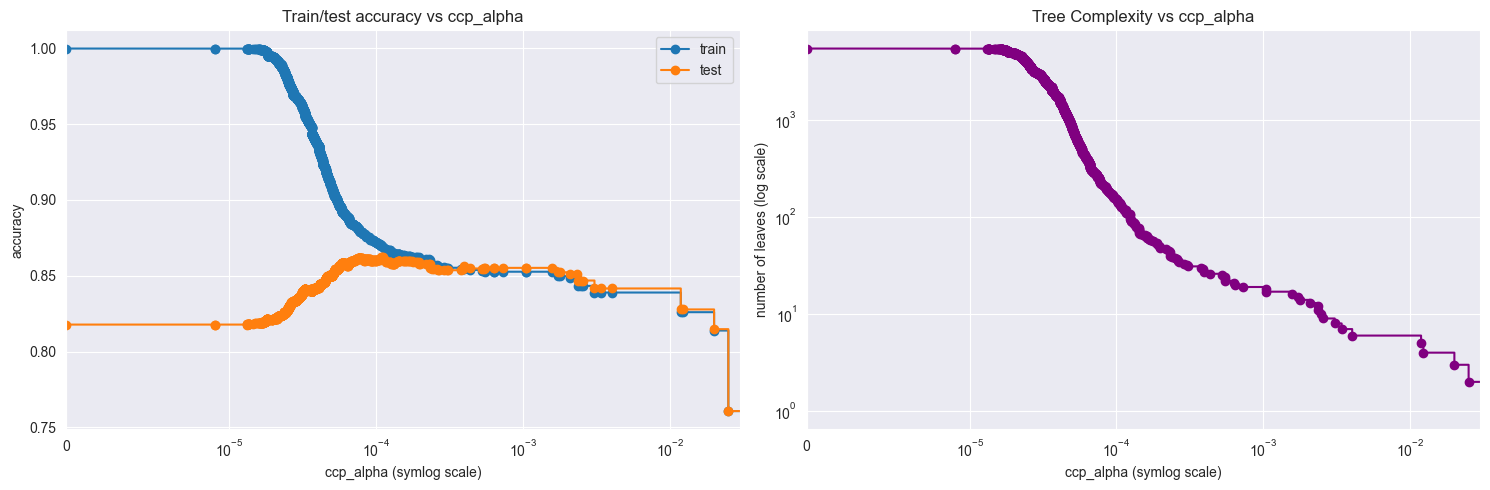

In [10]:
X_train_trans = preproc.fit_transform(X_train)
X_test_trans = preproc.transform(X_test)

clf_full = DecisionTreeClassifier(random_state=RNG)
path = clf_full.cost_complexity_pruning_path(X_train_trans, y_train)
ccp_alphas = path.ccp_alphas

train_scores = []
test_scores = []
depths = []
leaves = []

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=RNG, ccp_alpha=alpha)
    model.fit(X_train_trans, y_train)

    train_scores.append(model.score(X_train_trans, y_train))
    test_scores.append(model.score(X_test_trans, y_test))
    depths.append(model.get_depth())
    leaves.append(model.get_n_leaves())

fig, ax = plt.subplots(1, 2, figsize=(15, 5))

ax[0].plot(ccp_alphas, train_scores, marker='o', label='train', drawstyle='steps-post')
ax[0].plot(ccp_alphas, test_scores, marker='o', label='test', drawstyle='steps-post')
ax[0].set_title('Train/test accuracy vs ccp_alpha')
ax[0].set_xlabel('ccp_alpha (symlog scale)')
ax[0].set_ylabel('accuracy')
ax[0].set_xscale('symlog', linthresh=1e-5)
ax[0].set_xlim(0, 3e-2)
ax[0].legend()

ax[1].plot(ccp_alphas, leaves, marker='o', color='purple', drawstyle='steps-post')
ax[1].set_title('Tree Complexity vs ccp_alpha')
ax[1].set_xlabel('ccp_alpha (symlog scale)')
ax[1].set_ylabel('number of leaves (log scale)')
ax[1].set_xscale('symlog', linthresh=1e-5)
ax[1].set_yscale('log')
ax[1].set_xlim(0, 3e-2)

plt.tight_layout()
plt.show()

Lewy wykres przedstawia zmianę skuteczności modelu w zależności od parametru `ccp_alpha`. Dla alfa równego 0 drzewo jest pełne, występuje overfitting. Model uczy się zbioru treningowego na pamięć, więc doskonale sobie radzi na zbiorze treningowym, natomiast na zbiorze testowym zdecydowanie słabiej. Wraz ze wzrostem kary drzewo redukuje swoją głębokość, więc model coraz lepiej radzi sobie na danych testowych i w pewnym momencie osiaga punkt optymalny. Dalsze zwiększanie alfa sprawia, że model staje się zbyt prosty i jego skuteczność drastycznie spada, aż w końcu redukuje się do korzenia.

Prawy wykres potwierdza to zjawisko, pokazuje jak wraz ze wzrostem wartości alfa złożoność drzewa maleje, od tysięcy liści przy braku regularyzacji, aż do redukcji do samego korzenia przy maksymalnym alfa.

6. Wyznacz optymalne α
∗ przez GridSearchCV z param grid={’ccp alpha’:
alphas} na 10-krotnej CV.

In [11]:
from sklearn.model_selection import GridSearchCV

param_grid = {'ccp_alpha': ccp_alphas}
clf_cv = DecisionTreeClassifier(random_state=RNG)

grid_search = GridSearchCV(
    estimator=clf_cv,
    param_grid=param_grid,
    cv=kf,
    scoring='balanced_accuracy',
    n_jobs=-1
)

grid_search.fit(X_train_trans, y_train)

best_alpha = grid_search.best_params_['ccp_alpha']
print(f"Optimal ccp_alpha: {best_alpha}")
print(f"Best CV balanced_accuracy: {grid_search.best_score_:.4f}")

Optimal ccp_alpha: 0.0002493867153733889
Best CV balanced_accuracy: 0.7760


7. Porównanie strategii regularyzacji. Zbuduj tabelę porównawczą czterech modeli:

    a) pełne drzewo,

    b) pre-pruning z max depth=best d,

    c) pre-pruning kombinowane (max depth=10, min samples leaf=20, min impurity decrease=1e-4),

    d) post-pruning z ccp alpha=α∗.

    Kolumny: głębokość, liczba liści, train/test accuracy, f1, overfit gap. Skomentuj: którą strategię wybrałbyś do produkcji i dlaczego?

In [12]:
from sklearn.metrics import f1_score, balanced_accuracy_score

models = {
    'full tree': DecisionTreeClassifier(random_state=RNG),
    'pre-pruning (max_depth)': DecisionTreeClassifier(max_depth=best_d, random_state=RNG),
    'pre-pruning (combined)': DecisionTreeClassifier(
        max_depth=10,
        min_samples_leaf=20,
        min_impurity_decrease=1e-4,
        random_state=RNG
    ),
    'post-pruning (ccp)': DecisionTreeClassifier(ccp_alpha=best_alpha, random_state=RNG)
}

results = []

for name, clf in models.items():
    clf.fit(X_train_trans, y_train)

    y_train_pred = clf.predict(X_train_trans)
    y_test_pred = clf.predict(X_test_trans)

    depth = clf.get_depth()
    leaves = clf.get_n_leaves()
    train_acc = clf.score(X_train_trans, y_train)
    test_acc = clf.score(X_test_trans, y_test)
    f1 = f1_score(y_test, y_test_pred)
    overfit_gap = train_acc - test_acc

    results.append({
        'model': name,
        'depth': depth,
        'leaves': leaves,
        'train acc': train_acc,
        'test acc': test_acc,
        'f1 score': f1,
        'overfit gap': overfit_gap
    })

comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.round({'train acc': 4, 'test acc': 4, 'f1 score': 4, 'overfit gap': 4})
comparison_df

,model,depth,leaves,train acc,test acc,f1 score,overfit gap
0,full tree,44,5450,0.9999,0.8178,0.6250,0.1822
1,pre-pruning (max_depth),10,292,0.8674,0.8559,0.6787,0.0116
2,pre-pruning (combined),10,68,0.8589,0.8556,0.6749,0.0033
3,post-pruning (ccp),12,38,0.8572,0.8544,0.6771,0.0028


Do wdrożenia produkcyjnego wybrałabym model oparty na post-pruningu, ponieważ oferuje on najbardziej optymalny kompromis między jakością a prostotą. Mimo że model ten posiada zaledwie 38 liści, utrzymuje on bardzo wysokie accuracy i miarę f1 na poziomie 0.6771. Najważniejszym argumentem jest najniższy overfit gap, co oznacza, że model niemal idealnie generalizuje wiedzę i nie uczy się szumu. Myślę, że w warunkach produkcyjnych tak małe i stabilne drzewo jest latwiejsze do interpretacji, szybsze w działaniu i obarczone najmniejszym ryzykiem błędu przy pojawieniu się nowych, nieznanych wcześniej danych.

8. Wizualizacja drzewa. Dla drzewa ograniczonego do głębokości 3 wygeneruj:
- wizualizację przez export graphviz() → graphviz.Source(),
- wizualizację przez dtreeviz (histogramy rozkładu w węzłach, pie charts
w liściach).

Porównaj obydwie reprezentacje

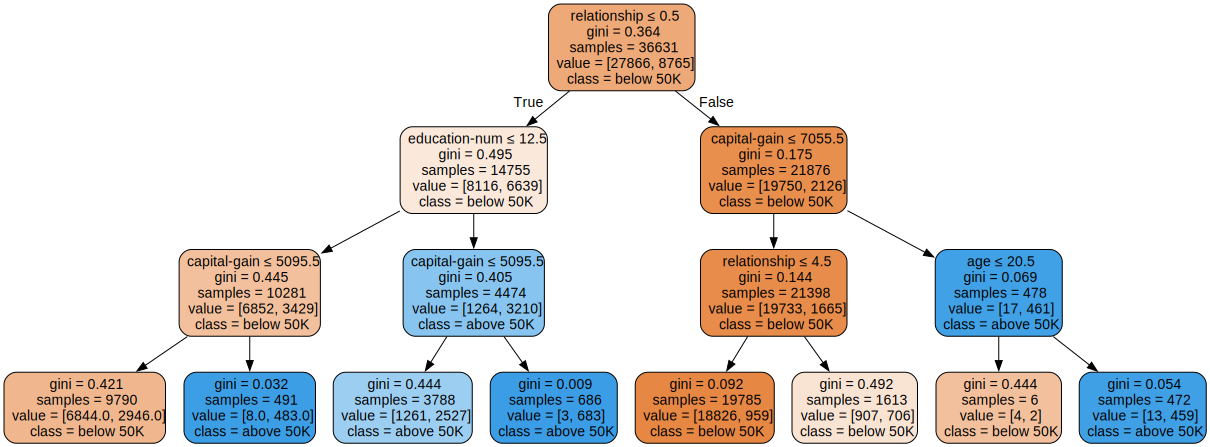

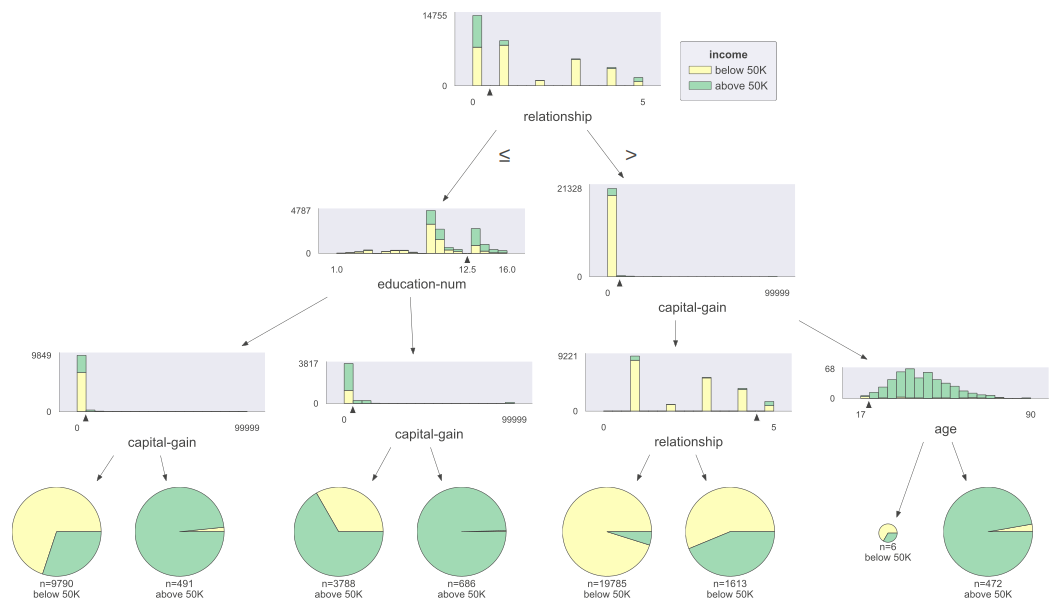

In [13]:
import graphviz
from sklearn.tree import export_graphviz
import dtreeviz

clf_viz = DecisionTreeClassifier(max_depth=3, random_state=RNG)
clf_viz.fit(X_train_trans, y_train)

dot_data = export_graphviz(
    clf_viz,
    out_file=None,
    feature_names=feature_names,
    class_names=['below 50K', 'above 50K'],
    filled=True,
    rounded=True,
    special_characters=True
)
graph = graphviz.Source(dot_data)
graph.render("tree_graphviz")
display(graph)

viz_model = dtreeviz.model(
    clf_viz,
    X_train=X_train_trans,
    y_train=y_train,
    feature_names=feature_names,
    target_name='income',
    class_names=['below 50K', 'above 50K']
)

v = viz_model.view(scale=1.5)
v.save("tree_dtreeviz.svg")
display(v)

Najważniejszym predyktorem okazała się zmienna relationship, ktora dokonuje pierwszego podziału danych i wyznacza kierunek dalszej klasyfikacji. W lewej gałęzi kluczową rolę odgrywa poziom wykształcenia oraz zysk kapitałowy, natomiast w prawej zysk kapitałowy, wiek oraz status rodzinny. Wysoki zysk kapitałowy powyżej 7055,5 jest silnym predyktorem dochodu powyżej 50k, co potwierdza niska wartość współczynnika Giniego wynosząca 0,175. W kolejnym węźle, opartym na wieku, wartość ta spada do 0,069, co oznacza niemal pewną klasyfikację do klasy powyżej 50k. Osoby z niskim wykształceniem i niskim zyskiem kapitałowym są natomiast klasyfikowane jako zarabiające poniżej 50k z wysoką pewnością.

Pierwsza wizualizacja przedstawia klasyczną strukturę drzewa z dokładnymi wartościami liczbowymi w każdym węźle, co czyni ją przydatną z perspektywy analitycznej. Druga wzbogaca tę strukturę o histogramy rozkładu cech oraz wykresy kołowe w liściach, dzięki czemu jest bardziej przystępna i lepiej sprawdza się podczas prezentacji wyników.

9. Interpretowalność. Dla drzewa przyciętego CCP wyznacz trzy rodzaje
feature importance:

    a) built-in (feature importances ),

    b) permutation importance na zbiorze testowym,

    c) wartości SHAP (shap.TreeExplainer): shap.summary plot dla 1000
    losowych rekordów oraz shap.plots.waterfall dla jednej wybranej
    predykcji.

Skomentuj: czy rankingi z trzech metod są spójne? Skąd mogą się brać różnice?

C:\Users\karol\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html


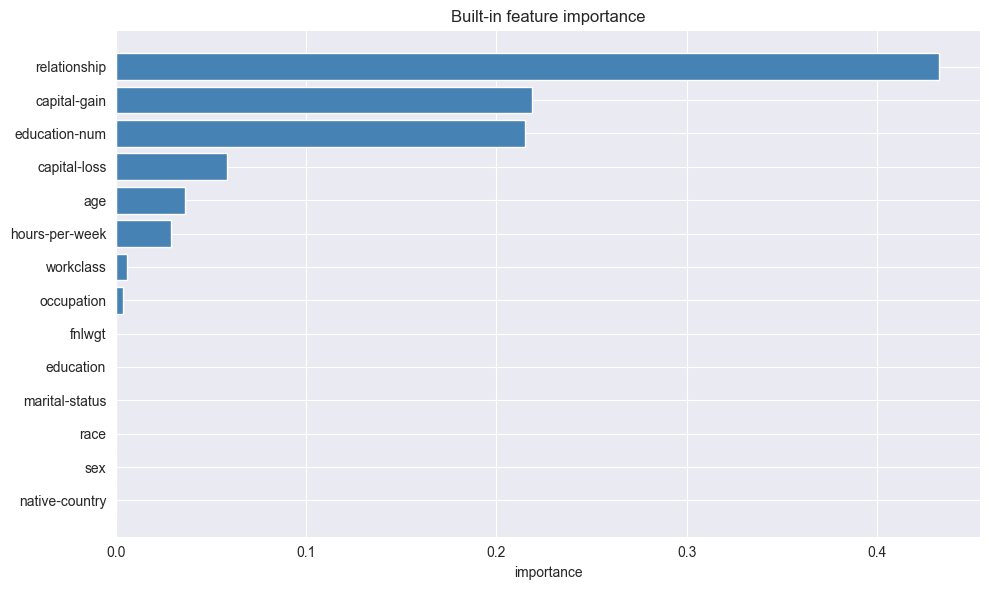

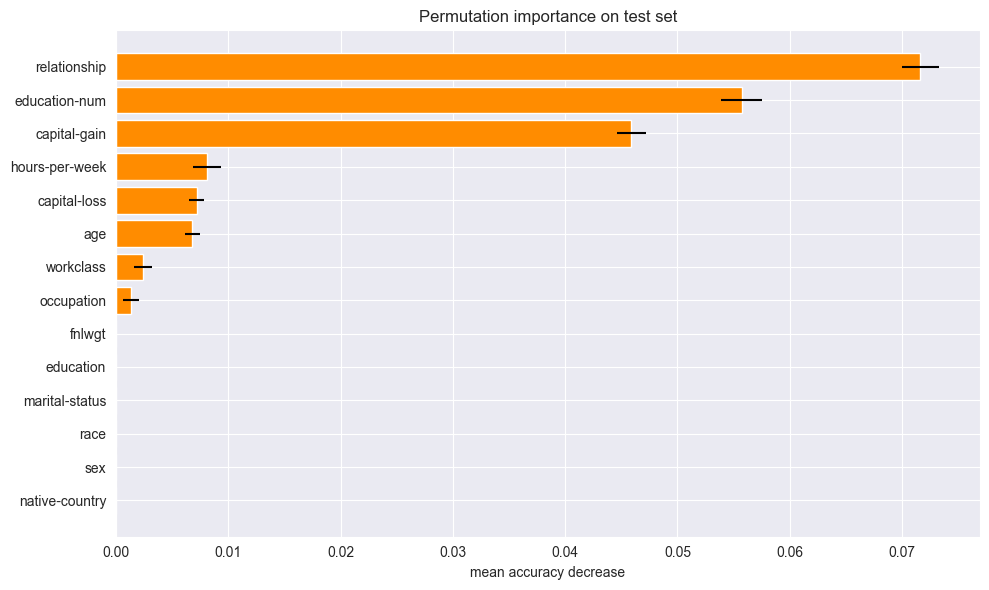

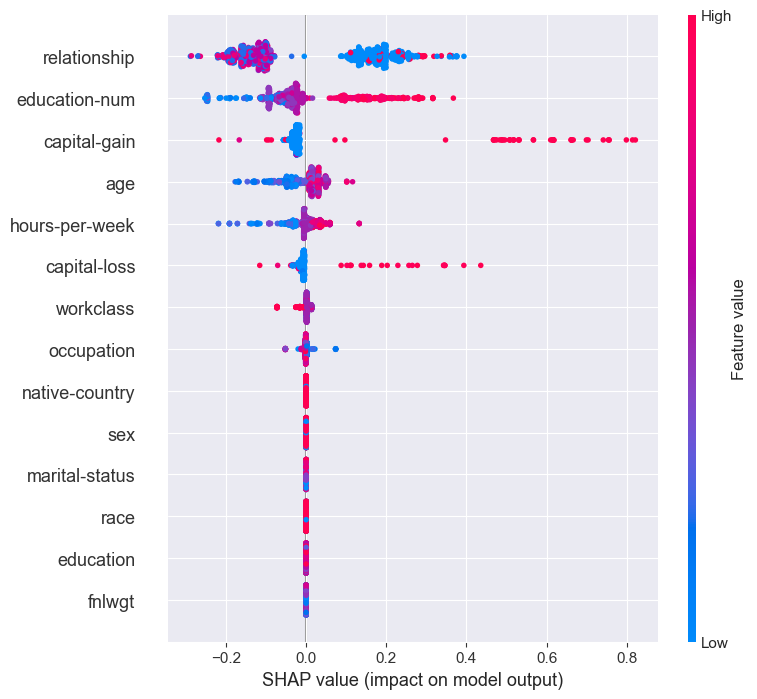

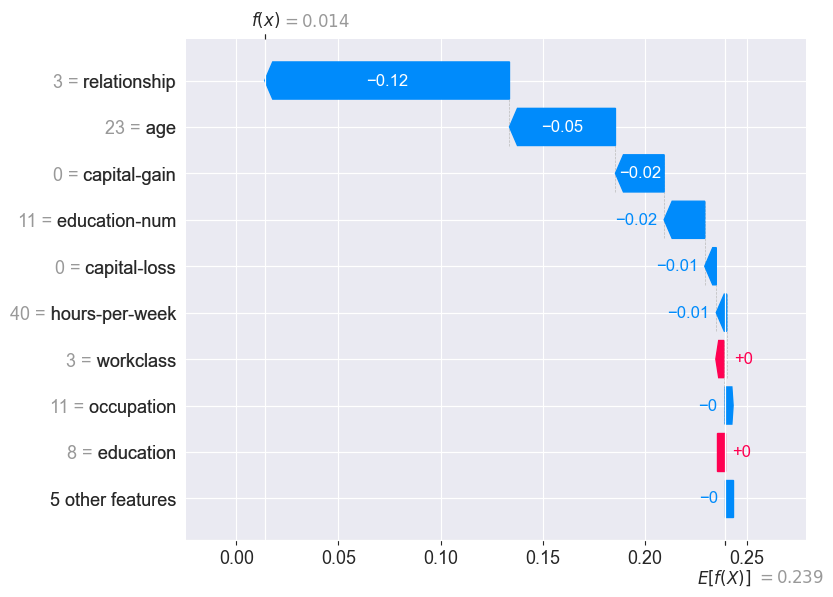

In [14]:
import shap
from sklearn.inspection import permutation_importance

clf_ccp = DecisionTreeClassifier(ccp_alpha=best_alpha, random_state=RNG)
clf_ccp.fit(X_train_trans, y_train)

# Built-in feature importance
fi_df = pd.DataFrame({
    'feature': feature_names,
    'importance': clf_ccp.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(fi_df['feature'][:15][::-1], fi_df['importance'][:15][::-1], color='steelblue')
plt.title('Built-in feature importance')
plt.xlabel('importance')
plt.tight_layout()
plt.show()

# Permutation importance
perm = permutation_importance(
    clf_ccp, X_test_trans, y_test,
    n_repeats=10,
    random_state=RNG,
    n_jobs=-1
)

perm_df = pd.DataFrame({
    'feature': feature_names,
    'importance_mean': perm.importances_mean,
    'importance_std':  perm.importances_std
}).sort_values('importance_mean', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(
    perm_df['feature'][:15][::-1],
    perm_df['importance_mean'][:15][::-1],
    xerr=perm_df['importance_std'][:15][::-1],
    color='darkorange'
)
plt.title('Permutation importance on test set')
plt.xlabel('mean accuracy decrease')
plt.tight_layout()
plt.show()

# SHAP
explainer = shap.TreeExplainer(clf_ccp)
X_test_df = pd.DataFrame(X_test_trans, columns=feature_names)
X_test_sample = X_test_df.sample(n=1000, random_state=RNG)
shap_values = explainer(X_test_sample)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values[:, :, 1], X_test_sample)

shap.plots.waterfall(shap_values[0, :, 1])

We wszystkich trzech metodach dominują te same trzy cechy: relationship, capital-gain oraz education-num, co świadczy o ogólnej spójności rankingów. Różnice pojawiają się natomiast na niższych pozycjach. Co ciekawe w built-in importance capital-gain i education-num mają niemal identyczną wartość, natomiast permutation importance i SHAP wyraznie wskazują na przewagę education-num nad capital-gain. Zapewne wynika to z charakteru built-in importance, która mierzy redukcję nieczystości w węzłach drzewa i jest podatna na bias wobec cech ciągłych o wielu unikalnych wartościach, co może sztucznie zawyżać znaczenie capital-gain.

Waterfall plot dla wybranej predykcji pokazuje, ze model przypisuje jej bardzo niskie prawdopodobieństwo klasy >50k. Głównym czynnikiem obniżającym predykcję jest relationship z wartością 3, a następnie age = 23, co jest spójne z rankingami globalnymi. Ogólnie SHAP dostarcza tu informacji niedostępnej w pozostałych metodach, ponieważ pokazuje nie tylko które cechy są ważne, ale też w jakim kierunku i z jaką siłą wpływają na konkretną predykcję.

10. ⋆ Wykonaj fairness audit: czy model przewiduje klasę pozytywną z różną dokładnością dla podgrup ze względu na płeć (sex) i rasę (race)?
Porównaj demographic parity i equalized odds w obu podgrupach.

In [15]:
from sklearn.metrics import confusion_matrix

y_pred = clf_ccp.predict(X_test_trans)

audit_df = X_test.copy()
audit_df['y_true'] = y_test.values
audit_df['y_pred'] = y_pred

def fairness_metrics(df, group_col):
    results = []
    for group, subset in df.groupby(group_col, observed=True):
        tn, fp, fn, tp = confusion_matrix(subset['y_true'], subset['y_pred']).ravel()
        results.append({
            'group': group,
            'n': len(subset),
            'demographic_parity': subset['y_pred'].mean(),
            'TPR':  tp / (tp + fn),
            'FPR':                fp / (fp + tn),
            'accuracy':           (tp + tn) / len(subset)
        })
    return pd.DataFrame(results).set_index('group').round(4)

display(fairness_metrics(audit_df, 'sex'))
display(fairness_metrics(audit_df, 'race'))

,n,demographic_parity,TPR,FPR,accuracy
group,,,,,
Female,4024,0.1016,0.6071,0.0375,0.9225
Male,8187,0.2657,0.6436,0.1025,0.8209


,n,demographic_parity,TPR,FPR,accuracy
group,,,,,
Amer-Indian-Eskimo,118,0.1102,0.5556,0.0300,0.9068
Asian-Pac-Islander,393,0.2774,0.6667,0.1409,0.8092
Black,1208,0.1126,0.6184,0.0398,0.9172
Other,107,0.1215,0.5455,0.0729,0.8879
White,10385,0.2227,0.6389,0.0809,0.8479


**Płeć**

Wyniki wskazują na wyraźne naruszenie demographic parity. Model przewiduje klasę >50k dla 26.6% mężczyzn, ale zaledwie dla 10.2% kobiet. Różnica jest ponad dwukrotna, więc występuje bias względem płci.
Equalized odds również nie jest spełnione. TPR jest zbliżony, co oznacza że model podobnie dobrze wykrywa faktycznie dobrze zarabiające osoby w obu grupach, jednak FPR różni się znacząco, mamy 0.10 dla mężczyzn wobec 0.04 dla kobiet. Model rzadziej fałszywie przyznaje kobietom klasę >50K, co w połączeniu z niskim demographic parity sugeruje, że model rzadko przewiduje im wysoki dochód nawet gdy jest to uzasadnione.

**Rasa**

Tutaj różnice są jeszcze wyraźniejsze. Demographic parity waha się od 0.11 dla Black i Amer-Indian-Eskimo do 0.28 dla Asian-Pac-Islander. Model najczęściej przyznaje klasę >50K osobom białym i azjatyckim, a najrzadziej czarnoskórym i rdzennym Amerykanom. TPR jest najniższy dla grupy Other 0.55 i Amer-Indian-Eskimo 0.56, co oznacza że model najczęściej przegapia faktycznie dobrze zarabiające osoby z tych grup. FPR jest najwyższy dla Asian-Pac-Islander (0.14), gdzie model najczęściej błędnie przyznaje klasę >50K.

Model narusza zarówno demographic parity jak i equalized odds dla obu atrybutów wrażliwych. Różnice te prawdopodobnie wynikają z historycznych nierówności w danych treningowych.

# Lasy losowe

1. Zbadaj zbieżność lasu losowego przy wzroście n estimators. Wykorzystaj warm start=True: dla n ∈ {10, 20, 50, 100, 200, 300, 500} dotrenuj
model i zapisz OOB score oraz test accuracy. Narysuj krzywą zbieżności.

n_estimators=  10 | OOB: 0.8331 | Test: 0.8523
n_estimators=  20 | OOB: 0.8413 | Test: 0.8541
n_estimators=  50 | OOB: 0.8493 | Test: 0.8572
n_estimators= 100 | OOB: 0.8523 | Test: 0.8581
n_estimators= 200 | OOB: 0.8534 | Test: 0.8600
n_estimators= 300 | OOB: 0.8546 | Test: 0.8593
n_estimators= 500 | OOB: 0.8547 | Test: 0.8590


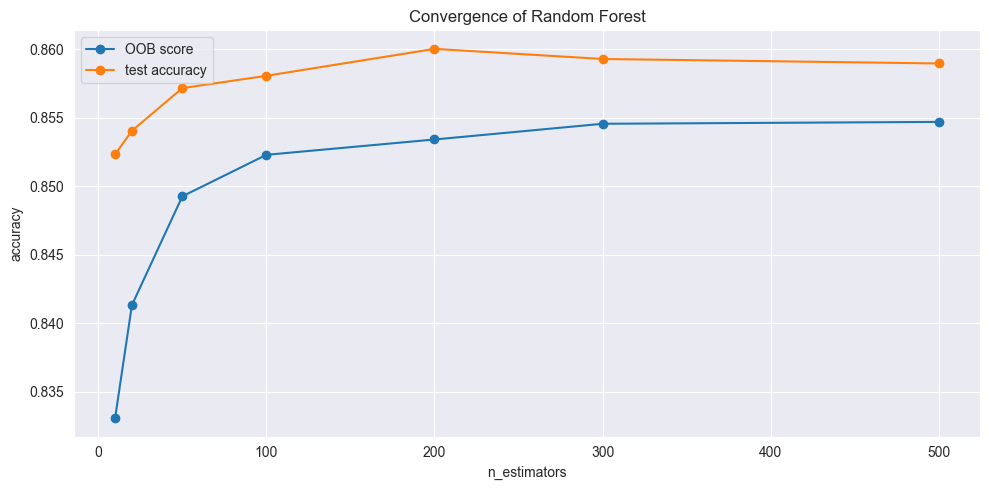

In [16]:
import warnings
from sklearn.ensemble import RandomForestClassifier
warnings.filterwarnings('ignore', category=UserWarning)

n_estimators_list = [10, 20, 50, 100, 200, 300, 500]

rf = RandomForestClassifier(warm_start=True, oob_score=True, random_state=RNG, n_jobs=-1)

oob_scores = []
test_scores = []

for n in n_estimators_list:
    rf.set_params(n_estimators=n)
    rf.fit(X_train_trans, y_train)
    oob_scores.append(rf.oob_score_)
    test_scores.append(rf.score(X_test_trans, y_test))
    print(f"n_estimators={n:4d} | OOB: {rf.oob_score_:.4f} | Test: {test_scores[-1]:.4f}")

plt.figure(figsize=(10, 5))
plt.plot(n_estimators_list, oob_scores, marker='o', label='OOB score')
plt.plot(n_estimators_list, test_scores, marker='o', label='test accuracy')
plt.xlabel('n_estimators')
plt.ylabel('accuracy')
plt.title('Convergence of Random Forest')
plt.legend()
plt.tight_layout()
plt.show()

Obie krzywe zbiegają się wraz ze wzrostem liczby drzew, testowa stabilizuje się przy 200 drzewach, a OOB na 300. Dalsze dodawanie drzew nie przynosi poprawy. OOB score konsekwentnie zaniża test accuracy, co potwierdza że jest dobrym, choć lekko pesymistycznym estymatorem generalizacji. Za optymalną liczbę drzew można przyjąć 200, gdzie model osiąga najwyższe test accuracy 0.8600 przy rozsądnym koszcie obliczeniowym.

2. Zbadaj wpływ max features ∈ {1, 2, 4, ’sqrt’, ’log2’, 0.5, None} przy n estimators=200.
Zbuduj tabelę OOB vs test. Skomentuj: jaka wartość daje najlepszy kompromis? Dlaczego skrajne wartości szkodzą?

In [17]:
max_features_list = [1, 2, 4, 'sqrt', 'log2', 0.5, None]

results = []

for mf in max_features_list:
    rf = RandomForestClassifier(
        n_estimators=200,
        max_features=mf,
        oob_score=True,
        random_state=RNG,
        n_jobs=-1
    )
    rf.fit(X_train_trans, y_train)
    results.append({
        'max_features': str(mf),
        'OOB score':    round(rf.oob_score_, 4),
        'test accuracy': round(rf.score(X_test_trans, y_test), 4)
    })

results_df = pd.DataFrame(results).set_index('max_features')
display(results_df)

,OOB score,test accuracy
max_features,,
1,0.8526,0.8575
2,0.8543,0.8600
4,0.8542,0.8598
sqrt,0.8534,0.8600
log2,0.8534,0.8600
0.5,0.8538,0.8591
None,0.8512,0.8569


Najlepszy kompromis daje wartość `2`, która osiąga najwyższy OOB score przy jednoczesnym test accuracy 0.8600 równym `sqrt` i `log2`. Wartosci `sqrt` i `log2` sprawdzają się zgodnie z teorią jako rekomendowany punkt startowy dla zadań klasyfikacji. Wartość 4 też poradziła sobie dobrze. `1` daje najniższy OOB score, dlatego, że każde drzewo widzi tylko jedną cechę w węźle, więc pojedyncze drzewa są zbyt słabe i losowe, mimo niskiej korelacji między nimi. Kolejna wartość skrajna `None` również wypada słabiej, drzewa dla tej wartości rozważają wszystkie cechy, są do siebie bardzo podobne i wysoka korelacja między nimi niweluje korzyści z uśredniania, co potwierdzają nasze wyniki.

3. ⋆ Optymalizacja bayesowska. Korzystając z biblioteki Optuna zoptymalizuj hiperparametry RF

In [18]:
import optuna

def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 50, 500, step=50),
        'max_depth':         trial.suggest_int('max_depth', 3, 30),
        'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.3, 0.5, 0.8]),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 30),
    }
    rf = RandomForestClassifier(**params, random_state=RNG, n_jobs=-1)
    return cross_val_score(rf, X_train_trans, y_train, cv=5, scoring='balanced_accuracy', n_jobs=-1).mean()

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RNG))
study.optimize(objective, n_trials=25)

print(f"Najlepsze hiperparametry: {study.best_params}")
print(f"Najlepszy wynik CV: {study.best_value:.4f}")

[I 2026-04-29 13:52:30,587] A new study created in memory with name: no-name-2bd612a6-fdeb-4122-aab8-dcde047ec2bd
[I 2026-04-29 13:52:33,536] Trial 0 finished with value: 0.7650817372703778 and parameters: {'n_estimators': 200, 'max_depth': 29, 'max_features': 'sqrt', 'min_samples_leaf': 18, 'min_samples_split': 19}. Best is trial 0 with value: 0.7650817372703778.
[I 2026-04-29 13:52:36,481] Trial 1 finished with value: 0.6621564180216218 and parameters: {'n_estimators': 400, 'max_depth': 3, 'max_features': 'sqrt', 'min_samples_leaf': 7, 'min_samples_split': 17}. Best is trial 0 with value: 0.7650817372703778.
[I 2026-04-29 13:52:39,684] Trial 2 finished with value: 0.7553359982661063 and parameters: {'n_estimators': 250, 'max_depth': 11, 'max_features': 'sqrt', 'min_samples_leaf': 16, 'min_samples_split': 7}. Best is trial 0 with value: 0.7650817372703778.
[I 2026-04-29 13:52:50,603] Trial 3 finished with value: 0.772043725582306 and parameters: {'n_estimators': 300, 'max_depth': 19, 

Najlepsze hiperparametry: {'n_estimators': 100, 'max_depth': 30, 'max_features': 0.3, 'min_samples_leaf': 3, 'min_samples_split': 20}
Najlepszy wynik CV: 0.7777


Optymalizacja bayesowska znalazła najlepszy zestaw hiperparametrów po 25 próbach, osiągając balanced accuracy 0.7777 na 5krotnej CV. Model preferuje umiarkowaną liczbę drzew (100), dużą głębokość (30), niewielki podzbiór cech (0.3), wysoką wartość min_samples_split (20) i niską min_samples_leaf (3), co ogranicza nadmierne dopasowanie. Warto zauważyć, że balanced accuracy jest niższe niż zwykłe accuracy, bo uśrednia TPR obu klas nie pozwalając klasie większościowej <50k dominować wyniku.

4. Porównaj najlepszy Random Forest z HistGradientBoostingClassifier
(domyślne parametry, max iter=300). Zbuduj tabelę: Decision Tree (CCP)
/ Random Forest (Optuna) / HistGradientBoosting. Skomentuj: który
model wygrywa i jaką cenę płacisz za poprawę jakości?

In [19]:
from sklearn.ensemble import HistGradientBoostingClassifier

rf_best = RandomForestClassifier(**study.best_params, random_state=RNG, n_jobs=-1)
rf_best.fit(X_train_trans, y_train)

hgb = HistGradientBoostingClassifier(max_iter=300, random_state=RNG)
hgb.fit(X_train_trans, y_train)

models = {
    'Decision Tree (CCP)':      clf_ccp,
    'Random Forest (Optuna)':   rf_best,
    'HistGradientBoosting':     hgb
}

results = []
for name, model in models.items():
    y_pred = model.predict(X_test_trans)
    results.append({
        'model':                name,
        'test accuracy':        round(model.score(X_test_trans, y_test), 4),
        'balanced accuracy':    round(balanced_accuracy_score(y_test, y_pred), 4),
        'f1 score':             round(f1_score(y_test, y_pred), 4)
    })

pd.DataFrame(results).set_index('model')

,test accuracy,balanced accuracy,f1 score
model,,,
Decision Tree (CCP),0.8544,0.7802,0.6771
Random Forest (Optuna),0.8670,0.7802,0.6883
HistGradientBoosting,0.8767,0.8004,0.7173


HistGradientBoosting wygrywa we wszystkich trzech metrykach, osiąga najwyższe test accuracy, balanced accuracy i f1 score. Random Forest z Optuna poprawia test accuracy względem Decision Tree, ale balanced accuracy pozostaje identyczne, z czego mozna wnioskować, że poprawa dotyczyła głównie klasy większościowej.

Jak widać zachodzi tutaj trade-off accuracy vs interpretability. Ceną za lepszą jakość HistGradientBoosting jest interpretowalność, tj model jest znacznie trudniejszy do zrozumienia i wyjaśnienia niż drzewo decyzyjne. Dodatkowo boosting jest bardziej wrażliwy na hiperparametry i trenowany sekwencyjnie, co oznacza że nie można go zrównoleglić tak jak Random Forest. W zastosowaniach gdzie interpretowalność jest kluczowa prostszy model może być lepszym wyborem mimo niższej dokładności.

# Klasyfikator k-NN

1. Załaduj zbiór Palmer Penguins (fetch openml(’penguins’, version=1)).
Usuń NaN, zakoduj cechy kategoryczne i etykietę, zastosuj StandardScaler.
Uzasadnij konieczność skalowania dla k-NN.

In [20]:
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

ds = fetch_openml('penguins', version=1, as_frame=True, parser='auto')
df = ds.frame.dropna().copy()

le = LabelEncoder()
y = le.fit_transform(df['species'])
X = df.drop(columns='species')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RNG
)

cat_cols = ['island', 'sex']
num_cols = ['culmen_length_mm', 'culmen_depth_mm', 'flipper_length_mm', 'body_mass_g']

preproc = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(),  cat_cols)
])

X_train_scaled = preproc.fit_transform(X_train)
X_test_scaled  = preproc.transform(X_test)

print(f"Train: {X_train_scaled.shape} | Test: {X_test_scaled.shape}")
print(f"Klasy: {le.classes_}")

Train: (250, 10) | Test: (84, 10)
Klasy: ['Adelie' 'Chinstrap' 'Gentoo']


k-NN klasyfikuje obserwacje na podstawie odległości do k najbliższych sąsiadów. Jeśli cechy mają różne skale to cecha o większych wartościach będzie dominować przy obliczaniu odległosci, nawet jeśli niesie mniej informacji. StandardScaler sprowadza wszystkie cechy do średniej 0 i odchylenia standardowego 1, dzięki czemu każda cecha ma równy wpływ na obliczaną odległość.

2. Przetestuj kombinacje k ∈ {1, 3, 5, 7, 9, 11, 15}, metric ∈ {euclidean, manhattan, chebyshev},
weights ∈ {uniform, distance}. Dla każdej kombinacji: 5-krotna CV accuracy. Zwizualizuj wyniki heatmapą

In [21]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import seaborn as sns

k_values = [1, 3, 5, 7, 9, 11, 15]
metrics = ['euclidean', 'manhattan', 'chebyshev']
weights_list = ['uniform', 'distance']

results = []
for w in weights_list:
    for m in metrics:
        for k in k_values:
            knn = KNeighborsClassifier(n_neighbors=k, metric=m, weights=w)
            score = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy').mean()
            results.append({'k': k, 'metric': m, 'weights': w, 'accuracy': score})

results_df = pd.DataFrame(results)

best = results_df.loc[results_df['accuracy'].idxmax()]
print(f"Najlepsze parametry: k={int(best['k'])}, metric={best['metric']}, weights={best['weights']}")
print(f"Najlepsza CV accuracy: {best['accuracy']:.4f}")

Najlepsze parametry: k=1, metric=euclidean, weights=uniform
Najlepsza CV accuracy: 0.9960


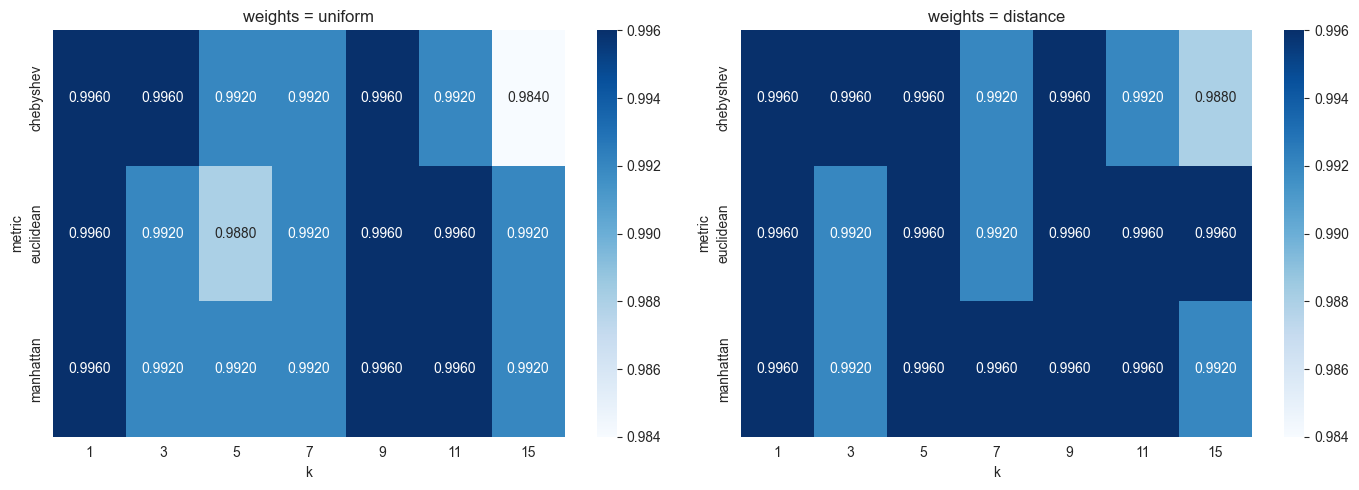

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, w in zip(axes, weights_list):
    pivot = results_df[results_df['weights'] == w].pivot(index='metric', columns='k', values='accuracy')
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='Blues', ax=ax, vmin=results_df['accuracy'].min())
    ax.set_title(f'weights = {w}')

plt.tight_layout()
plt.show()

Wyniki są bardzo wysokie i zbliżone dla wszystkich kombinacji 0.984-0.996. Wybór metryki i k ma marginalny wpływ, choć weights=distance daje nieco bardziej stabilne wyniki eliminując lokalne spadki przy większych k.

3. Powtórz analizę dla zbioru NYT-frame (zredukowanego przez PCA do 10
wymiarów). Zaobserwuj, jak wybór metryki zależy od wymiarowości.

In [23]:
from sklearn.decomposition import PCA

df_nyt = pd.read_csv('nyt-frame.csv')
X_nyt = df_nyt.select_dtypes(include=[np.number])
y_nyt = LabelEncoder().fit_transform(df_nyt.select_dtypes(include=['object']).iloc[:, 0])

X_nyt_train, X_nyt_test, y_nyt_train, y_nyt_test = train_test_split(
    X_nyt, y_nyt, test_size=0.25, random_state=RNG
)

scaler_nyt = StandardScaler()
X_nyt_train_scaled = scaler_nyt.fit_transform(X_nyt_train)
X_nyt_test_scaled  = scaler_nyt.transform(X_nyt_test)

pca = PCA(n_components=10, random_state=RNG)
X_nyt_train_pca = pca.fit_transform(X_nyt_train_scaled)
X_nyt_test_pca  = pca.transform(X_nyt_test_scaled)

print(f"Wyjaśniona wariancja: {pca.explained_variance_ratio_.sum():.4f}")

results_nyt = []
for w in weights_list:
    for m in metrics:
        for k in k_values:
            knn = KNeighborsClassifier(n_neighbors=k, metric=m, weights=w)
            score = cross_val_score(knn, X_nyt_train_pca, y_nyt_train, cv=5, scoring='accuracy').mean()
            results_nyt.append({'k': k, 'metric': m, 'weights': w, 'accuracy': score})

results_nyt_df = pd.DataFrame(results_nyt)

best_nyt = results_nyt_df.loc[results_nyt_df['accuracy'].idxmax()]
print(f"Najlepsze parametry: k={int(best_nyt['k'])}, metric={best_nyt['metric']}, weights={best_nyt['weights']}")
print(f"Najlepsza CV accuracy: {best_nyt['accuracy']:.4f}")

Wyjaśniona wariancja: 0.2123
Najlepsze parametry: k=15, metric=euclidean, weights=uniform
Najlepsza CV accuracy: 0.8025


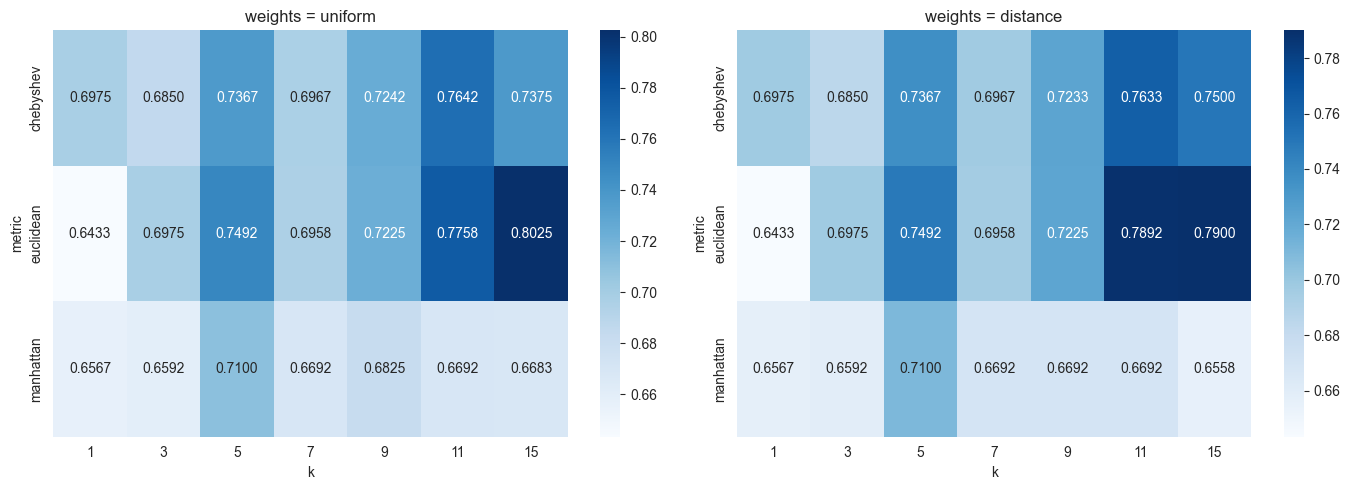

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, w in zip(axes, weights_list):
    pivot = results_nyt_df[results_nyt_df['weights'] == w].pivot(index='metric', columns='k', values='accuracy')
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='Blues', ax=ax, vmin=results_nyt_df['accuracy'].min())
    ax.set_title(f'weights = {w}')

plt.tight_layout()
plt.show()

W przeciwieństwie do zbioru pingwinów, wyniki dla NYT są znacznie niższe i bardziej zróżnicowane między metrykami. Najlepiej sprawdza się `euclidean`, `chebyshev` wypada pośrednio, podczas gdy `manhattan` wypada wyraźnie najgorzej. PCA redukuje dane do zaledwie 10 wymiarów, gdzie problem wysokiej wymiarowosci praktycznie znika i `euclidean` działa poprawnie. Gdyby k-NN był stosowany na oryginalnych wymiarach, można by oczekiwać przewagi `manhattan`. Warto też zauważyć że większe k daje lepsze wyniki niż małe, ponieważ przy trudniejszym zbiorze większe k sprawia, że decyzja opiera się na głosach wiekszej liczby sąsiadów co pomaga stabilizować predykcje.

4. ⋆
Implementacja własna KD-tree. Przetestuj na 10 000 losowych punktów 10D porównując czas wyszukiwania NN: brute-force (NumPy) vs
sklearn.neighbors.KDTree vs scipy.spatial.cKDTree.

In [25]:
import time
from sklearn.neighbors import KDTree
from scipy.spatial import cKDTree

np.random.seed(RNG)
X_random = np.random.randn(10000, 10)
query = np.random.randn(100, 10)

def brute_force_nn(X, query):
    results = []
    for q in query:
        dists = np.sqrt(((X - q) ** 2).sum(axis=1))
        results.append(np.argmin(dists))
    return results

start = time.time()
bf_results = brute_force_nn(X_random, query)
bf_time = time.time() - start

start = time.time()
sklearn_tree = KDTree(X_random)
sklearn_results = sklearn_tree.query(query, k=1)[1].flatten()
sklearn_time = time.time() - start

start = time.time()
scipy_tree = cKDTree(X_random)
scipy_results = scipy_tree.query(query, k=1)[1]
scipy_time = time.time() - start

results_df = pd.DataFrame([
    {'metoda': 'brute-force NumPy', 'czas [s]': round(bf_time, 4)},
    {'metoda': 'sklearn KDTree',    'czas [s]': round(sklearn_time, 4)},
    {'metoda': 'scipy cKDTree',     'czas [s]': round(scipy_time, 4)},
])
print(results_df.to_string(index=False))

print(f"\nZgodność wyników sklearn vs bf: {np.all(sklearn_results == bf_results)}")
print(f"Zgodność wyników scipy vs bf: {np.all(scipy_results == bf_results)}")

           metoda  czas [s]
brute-force NumPy    0.0622
   sklearn KDTree    0.0125
    scipy cKDTree    0.0143

Zgodność wyników sklearn vs bf: True
Zgodność wyników scipy vs bf: True


Wyniki metod są zgodne. Scipy cKDTree jest najszybsze, sklearn KDTree ponad dwukrotnie wolniejsze, a brute-force zdecydowanie najwolniejszy ze wszytskich.

5. ⋆ Wykonaj optymalizację bayesowską hiperparametrów k-NN (scikit-optimize
lub Optuna) w przestrzeni.

In [26]:
import optuna

# NYT
def objective(trial):
    params = {
        'n_neighbors': trial.suggest_int('n_neighbors', 1, 20),
        'metric':      trial.suggest_categorical('metric', ['euclidean', 'manhattan', 'cosine']),
        'weights':     trial.suggest_categorical('weights', ['uniform', 'distance'])
    }
    knn = KNeighborsClassifier(**params)
    return cross_val_score(knn, X_nyt_train_pca, y_nyt_train, cv=5, scoring='accuracy').mean()

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RNG))
study.optimize(objective, n_trials=50)

print(f"Najlepsza parametry: {study.best_params}")
print(f"Najlepsza CV accuracy: {study.best_value:.4f}")

[I 2026-04-29 13:54:01,847] A new study created in memory with name: no-name-f9da22d0-aef1-46b5-9a7f-9126d5df1169
[I 2026-04-29 13:54:01,862] Trial 0 finished with value: 0.7100000000000001 and parameters: {'n_neighbors': 8, 'metric': 'euclidean', 'weights': 'uniform'}. Best is trial 0 with value: 0.7100000000000001.
[I 2026-04-29 13:54:01,875] Trial 1 finished with value: 0.6433333333333333 and parameters: {'n_neighbors': 2, 'metric': 'euclidean', 'weights': 'distance'}. Best is trial 0 with value: 0.7100000000000001.
[I 2026-04-29 13:54:01,884] Trial 2 finished with value: 0.7625 and parameters: {'n_neighbors': 17, 'metric': 'euclidean', 'weights': 'distance'}. Best is trial 2 with value: 0.7625.
[I 2026-04-29 13:54:01,893] Trial 3 finished with value: 0.6691666666666667 and parameters: {'n_neighbors': 9, 'metric': 'manhattan', 'weights': 'distance'}. Best is trial 2 with value: 0.7625.
[I 2026-04-29 13:54:01,904] Trial 4 finished with value: 0.7233333333333333 and parameters: {'n_ne

Najlepsza parametry: {'n_neighbors': 15, 'metric': 'euclidean', 'weights': 'distance'}
Najlepsza CV accuracy: 0.7900


In [27]:
# PENGUINS
def objective_penguins(trial):
    params = {
        'n_neighbors': trial.suggest_int('n_neighbors', 1, 20),
        'metric':      trial.suggest_categorical('metric', ['euclidean', 'manhattan', 'cosine']),
        'weights':     trial.suggest_categorical('weights', ['uniform', 'distance'])
    }
    knn = KNeighborsClassifier(**params)
    return cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy').mean()

study_penguins = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=RNG))
study_penguins.optimize(objective_penguins, n_trials=50)

print(f"Najlepsza parametry: {study_penguins.best_params}")
print(f"Najlepsza CV accuracy: {study_penguins.best_value:.4f}")

[I 2026-04-29 13:54:02,441] A new study created in memory with name: no-name-f85573c4-8cb4-4a2d-965a-1464dd9b3933
[I 2026-04-29 13:54:02,458] Trial 0 finished with value: 0.9960000000000001 and parameters: {'n_neighbors': 8, 'metric': 'euclidean', 'weights': 'uniform'}. Best is trial 0 with value: 0.9960000000000001.
[I 2026-04-29 13:54:02,471] Trial 1 finished with value: 0.9960000000000001 and parameters: {'n_neighbors': 2, 'metric': 'euclidean', 'weights': 'distance'}. Best is trial 0 with value: 0.9960000000000001.
[I 2026-04-29 13:54:02,483] Trial 2 finished with value: 0.9960000000000001 and parameters: {'n_neighbors': 17, 'metric': 'euclidean', 'weights': 'distance'}. Best is trial 0 with value: 0.9960000000000001.
[I 2026-04-29 13:54:02,493] Trial 3 finished with value: 0.9960000000000001 and parameters: {'n_neighbors': 9, 'metric': 'manhattan', 'weights': 'distance'}. Best is trial 0 with value: 0.9960000000000001.
[I 2026-04-29 13:54:02,506] Trial 4 finished with value: 0.996

Najlepsza parametry: {'n_neighbors': 8, 'metric': 'euclidean', 'weights': 'uniform'}
Najlepsza CV accuracy: 0.9960


# Odpowiedzi na pytania

### 1. Która strategia regularyzacji drzewa (pre-pruning, post-pruning, hybryda) okazała się najskuteczniejsza i dlaczego?

Post-pruning okazał się najskuteczniejszy. Model osiągnął najniższy overfit gap, co oznacza że najlepiej generalizuje na nowe dane. W porównaniu z pełnym drzewem ma tylko 38 liści zamiast tysięcy, zachowując przy tym wysoka dokładność. Główna przewaga nad pre-pruningiem polega na tym że CCP automatycznie znajduje optymalną złożoność modelu bez konieczności ręcznego dobierania wielu parametrów jak max_depth czy min_samples_leaf. Post-pruning ocenia użyteczność gałęzi widząc już pełna strukturę danych, natomiast pre-pruning może zatrzymać algorytm przedwcześnie, omijając potencjalnie korzystne podziały na głębszych poziomach.

### 2. Czy rankingi cech według built-in importance, permutation importance i SHAP są spójne? Jak interpretować rozbieżności?

We wszystkich trzech metodach dominują te same cechy: relationship, capital-gain i education-num, więc główne rankingi są spójne, a różnice pojawiają się na niższych pozycjach. Built-in importance faworyzuje capital-gain bo ta metryka skupia się tylko na danych treningowych i preferuje cechy o wielu unikalnych wartosciach, nawet jeśli ich rzeczywisty wpływ jest mniejszy. Permutation importance i SHAP wyraźniej wskazują na przewagę education-num, bo mierzą faktyczny wpływ na predykcje na nowych danych, co pozwala zdemaskowac overfitting. SHAP dodatkowo pokazuje kierunek wpływu, czyli czy dana cecha zwiększa czy zmniejsza prawdopodobieństwo klasy pozytywnej dla konkretnej predykcji.

### 3. Jaki jest zysk Random Forest w porównaniu z pojedynczym drzewem, oraz gradient boostingu w stosunku do RF? Jaka jest cena tego zysku?

Random Forest poprawił test accuracy z 0.8544 do 0.8670 względem pojedynczego drzewa. Balanced accuracy pozostało jednak takie samo na poziomie 0.7802. HistGradientBoosting wygrał we wszystkich metrykach osiagając test accuracy 0.8767, balanced accuracy 0.8004 i f1 score 0.7173.

Ceną za lepszą jakość jest interpretowalność. Pojedyncze drzewo można przeczytać i zrozumieć dokładnie jak działa, a Random Forest to już setki drzew głosujących razem, więc trudniej wyjaśnić konkretną decyzję. Gradient boosting jest jeszcze bardziej skomplikowany bo każde kolejne drzewo poprawia błędy poprzedniego. Dodatkowo boosting trenuje się sekwencyjnie więc nie można go zrównoleglić jak Random Forest, co wydłuża czas uczenia.

### 4. Jak zachowuje się trade-off bias-variance w Random Forest w funkcji max features?

Parametr max_features zarządza bias-variance trade-off, kontrolując korelację między drzewami. Zmniejszanie tej wartości redukuje wariancję całego lasu poprzez wymuszanie różnorodności, jednak zbyt niska wartość drastycznie zwiększa bias, czyniąc pojedyncze drzewa zbyt słabymi.

Przy max_features równym 1 każde drzewo widzi tylko jedną cechę w każdym węźle, wiec pojedyncze drzewa są zbyt słabe i mają wysoką wariancję. Mimo że drzewa są od siebie różne, ich jakość jest na tyle niska że uśrednianie nie pomaga. Dało to najgorszy wynik z OOB score 0.8526.

Przy max_features równym None drzewa widzą wszystkie cechy, więc stają się bardzo podobne do siebie. Wysoka korelacja między drzewami sprawia że uśrednianie niewiele daje, bo wszystkie drzewa popełniają podobne błędy. Test accuracy w tym przypadku wyniosło 0.8569.

Najlepszy kompromis to wartość 2 lub ew sqrt i log2. Drzewa są wtedy wystarczająco silne żeby dobrze klasyfikować, ale jednocześnie wystarczająco różne żeby uśrednianie miało sens. Wartość 2 dała najwyższy OOB score przy test accuracy 0.8600, więc wydaje się być najlepszym wyborem.

### 5. Jakie zagrożenia fairness wiążą się ze stosowaniem modelu trenowanego na zbiorze Adult Census?

Model wyraznie dyskryminuje ze względu na płeć i rasę. Przewiduje wysokie dochody dla 26.6% mężczyzn ale tylko dla 10.2% kobiet. Dla różnych ras różnice są jeszcze większe, od 11% dla osób czarnoskórych i rdzennych Amerykanów do 28% dla osób azjatyckich.

Model też różnie dobrze wykrywa faktycznie dobrze zarabiające osoby w różnych grupach. Najgorzej radzi sobie z grupami Other i Amer-Indian-Eskimo gdzie TPR wynosi około 0.55, czyli przegapia prawie połowę osób które faktycznie zarabiają powyżej 50K.

Te różnice wynikają z historycznych nierówności w danych treningowych oraz z tego że model uczy się pośrednio z cech skorelowanych z płcią i rasą jak occupation czy relationship. Gdyby taki model został wdrożony do podejmowania decyzji, mógłby utrwalać i pogłębiać istniejące nierówności społeczne.